# DeepFashion-MultiModal Visual Preprocessing

**Owner:** Dasith  
**Purpose:** Prepare DeepFashion-MultiModal data for CLIP feature extraction and fashion attribute classification.

This notebook creates metadata manifests and reproducible split files only. It does not copy the image dataset, modify raw files, or train a model. The classification target and all reported results are discovered from the local label files at runtime.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

RANDOM_STATE = 42
IMAGE_SIZE = 224
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.10
FAST_DEV_RUN = False
EXCLUDE_NA_TARGET = True
MIN_CLASS_SAMPLES = 100
TARGET_NAME = 'lower_fabric'
FABRIC_LABEL_FILE = 'texture/fabric_ann.txt'
FABRIC_FIELDS = {
    'upper_fabric': f'{FABRIC_LABEL_FILE}__value_1',
    'lower_fabric': f'{FABRIC_LABEL_FILE}__value_2',
    'outer_fabric': f'{FABRIC_LABEL_FILE}__value_3',
}
FABRIC_ID_TO_LABEL = {
    0: 'denim', 1: 'cotton', 2: 'leather', 3: 'furry',
    4: 'knitted', 5: 'chiffon', 6: 'other', 7: 'NA',
}
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'config.yaml').is_file() and (candidate / 'data' / 'raw' / 'deepfashion').is_dir():
            return candidate
    raise FileNotFoundError('Project root with config.yaml and data/raw/deepfashion was not found.')

PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'deepfashion'
INTERIM_ROOT = PROJECT_ROOT / 'data' / 'interim'
INTERIM_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset root: {DATASET_ROOT}')
print(f'Configured target: {TARGET_NAME}; exclude NA: {EXCLUDE_NA_TARGET}; rare threshold: {MIN_CLASS_SAMPLES}')

Project root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI
Dataset root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\data\raw\deepfashion
Configured target: lower_fabric; exclude NA: True; rare threshold: 100


## 1. Discover images and inspect real labels

Label files are not assumed to have semantic headers. Each file is parsed as an image filename followed by its observed values, and columns retain the source filename and position.

In [2]:
image_root = DATASET_ROOT / 'images'
label_root = DATASET_ROOT / 'labels'
if not image_root.is_dir():
    raise FileNotFoundError(f'Missing image directory: {image_root}')
if not label_root.is_dir():
    raise FileNotFoundError(f'Missing label directory: {label_root}')

image_files = sorted(p for p in image_root.rglob('*') if p.is_file())
image_by_name = {}
for path in image_files:
    image_by_name.setdefault(path.name, []).append(path)
duplicate_image_names = {name: paths for name, paths in image_by_name.items() if len(paths) > 1}
print(f'Images: {len(image_files):,}; duplicate image basenames: {len(duplicate_image_names):,}')

def parse_value(token):
    try:
        return int(token)
    except ValueError:
        try:
            return float(token)
        except ValueError:
            return token

label_files = sorted(p for p in label_root.rglob('*') if p.is_file())
label_records = []
label_inventory = []
for label_path in label_files:
    relative_name = str(label_path.relative_to(label_root)).replace('\\', '/')
    record_count = 0
    malformed_lines = 0
    with label_path.open('r', encoding='utf-8', errors='replace') as handle:
        for line_number, line in enumerate(handle, start=1):
            tokens = line.strip().split()
            if not tokens:
                continue
            if len(tokens) < 2:
                malformed_lines += 1
                continue
            record_count += 1
            row = {'image_name': tokens[0], 'label_file': relative_name, 'line_number': line_number}
            for position, token in enumerate(tokens[1:], start=1):
                row[f'{relative_name}__value_{position}'] = parse_value(token)
            label_records.append(row)
    label_inventory.append({'label_file': relative_name, 'records': record_count, 'malformed_lines': malformed_lines})

labels_long = pd.DataFrame(label_records)
display(pd.DataFrame(label_inventory))
print(f'Parsed label records: {len(labels_long):,}')
display(labels_long.head())

Images: 44,096; duplicate image basenames: 0


,label_file,records,malformed_lines
0,shape/shape_anno_all.txt,42544,0
1,texture/fabric_ann.txt,44096,0
2,texture/pattern_ann.txt,44096,0


Parsed label records: 130,736


,image_name,label_file,line_number,shape/shape_anno_all.txt__value_1,shape/shape_anno_all.txt__value_2,shape/shape_anno_all.txt__value_3,shape/shape_anno_all.txt__value_4,shape/shape_anno_all.txt__value_5,shape/shape_anno_all.txt__value_6,shape/shape_anno_all.txt__value_7,...,shape/shape_anno_all.txt__value_9,shape/shape_anno_all.txt__value_10,shape/shape_anno_all.txt__value_11,shape/shape_anno_all.txt__value_12,texture/fabric_ann.txt__value_1,texture/fabric_ann.txt__value_2,texture/fabric_ann.txt__value_3,texture/pattern_ann.txt__value_1,texture/pattern_ann.txt__value_2,texture/pattern_ann.txt__value_3
0,MEN-Denim-id_00000080-01_7_additional.jpg,shape/shape_anno_all.txt,1,5.0,3.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,MEN-Denim-id_00000089-01_7_additional.jpg,shape/shape_anno_all.txt,2,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,MEN-Denim-id_00000089-02_7_additional.jpg,shape/shape_anno_all.txt,3,3.0,3.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,MEN-Denim-id_00000089-03_7_additional.jpg,shape/shape_anno_all.txt,4,1.0,3.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,MEN-Denim-id_00000089-04_7_additional.jpg,shape/shape_anno_all.txt,5,3.0,3.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Select the project-defined classification target

The project-defined semantic target is **lower_fabric**, represented by the observed `texture/fabric_ann.txt` value column selected in the code below. Candidate reports expose coverage and class balance for review; they do not automatically choose a different target.

In [3]:
value_columns = [c for c in labels_long.columns if c not in {'image_name', 'label_file', 'line_number'}]
for semantic_name, raw_column in FABRIC_FIELDS.items():
    if raw_column not in labels_long.columns:
        raise KeyError(f'Missing expected fabric field for {semantic_name}: {raw_column}')

image_by_name = {}
for path in image_files:
    image_by_name.setdefault(path.name, []).append(path)
duplicate_image_names = {name: paths for name, paths in image_by_name.items() if len(paths) > 1}

fabric_selection_rows = []
for semantic_name, raw_column in FABRIC_FIELDS.items():
    values = labels_long[['image_name', raw_column]].dropna()
    values = values[values['image_name'].isin(image_by_name)]
    counts = values[raw_column].map(FABRIC_ID_TO_LABEL).value_counts().sort_index()
    rare_classes = counts[counts < MIN_CLASS_SAMPLES].index.tolist()
    fabric_selection_rows.append({
        'semantic_target': semantic_name,
        'raw_column': raw_column,
        'matched_records': int(len(values)),
        'n_classes_including_NA': int(values[raw_column].nunique()),
        'na_count': int((values[raw_column] == 7).sum()),
        'na_percentage': float((values[raw_column] == 7).mean() * 100) if len(values) else 0.0,
        'minimum_class_count': int(counts.min()) if len(counts) else 0,
        'rare_classes_below_threshold': ', '.join(rare_classes) if rare_classes else 'none',
        'class_distribution': counts.to_dict(),
        'semantic_usefulness': 'fabric attribute classification',
    })
fabric_selection_report = pd.DataFrame(fabric_selection_rows)
TARGET_COLUMN = FABRIC_FIELDS[TARGET_NAME]
print(f'Selected semantic target: {TARGET_NAME} ({TARGET_COLUMN})')
display(fabric_selection_report)

target_source = labels_long[['image_name', TARGET_COLUMN]].dropna().copy()
target_source['target_raw_id'] = target_source[TARGET_COLUMN].astype(int)
target_source['target_raw_label'] = target_source['target_raw_id'].map(FABRIC_ID_TO_LABEL)
target_source = target_source[target_source['image_name'].isin(image_by_name)]
original_records = int(len(target_source))
removed_na_samples = int((target_source['target_raw_id'] == 7).sum()) if EXCLUDE_NA_TARGET else 0
target_after_na = target_source[target_source['target_raw_id'] != 7].copy() if EXCLUDE_NA_TARGET else target_source.copy()
raw_counts_after_na = target_after_na['target_raw_label'].value_counts().sort_index()
rare_labels = raw_counts_after_na[raw_counts_after_na < MIN_CLASS_SAMPLES].index.tolist()
rare_raw_ids = [label for label in FABRIC_ID_TO_LABEL if FABRIC_ID_TO_LABEL[label] in rare_labels]
removed_rare_class_samples = int(target_after_na['target_raw_label'].isin(rare_labels).sum())
target_records = target_after_na[~target_after_na['target_raw_label'].isin(rare_labels)].copy()
print(f'Original records: {original_records:,}; removed NA samples: {removed_na_samples:,}; rare classes: {rare_labels}; removed rare samples: {removed_rare_class_samples:,}')

duplicate_target_records = int(target_records.duplicated(['image_name']).sum())
conflicting_target_groups = target_records.groupby('image_name')['target_raw_id'].nunique()
conflicting_images = int((conflicting_target_groups > 1).sum())
if conflicting_images:
    raise ValueError('Conflicting labels were found for the selected target; refusing to create an ambiguous manifest.')
target_records = target_records.drop_duplicates('image_name', keep='first')
class_labels = sorted(target_records['target_raw_label'].unique())
label_to_id = {label: index for index, label in enumerate(class_labels)}
id_to_label = {str(index): label for label, index in label_to_id.items()}
target_records['target_id'] = target_records['target_raw_label'].map(label_to_id)
target_records['target_label'] = target_records['target_raw_label']
print(f'Final supervised records before path validation: {len(target_records):,}; classes: {class_labels}')
display(target_records.groupby(['target_id', 'target_label']).size().reset_index(name='count'))

Selected semantic target: lower_fabric (texture/fabric_ann.txt__value_2)


,semantic_target,raw_column,matched_records,n_classes_including_NA,na_count,na_percentage,minimum_class_count,rare_classes_below_threshold,class_distribution,semantic_usefulness
0,upper_fabric,texture/fabric_ann.txt__value_1,44096,8,998,2.263244,94,"leather, other","{'NA': 998, 'chiffon': 5142, 'cotton': 34734, ...",fabric attribute classification
1,lower_fabric,texture/fabric_ann.txt__value_2,44096,8,1326,3.007075,15,furry,"{'NA': 1326, 'chiffon': 2252, 'cotton': 19073,...",fabric attribute classification
2,outer_fabric,texture/fabric_ann.txt__value_3,44096,8,38471,87.243741,20,other,"{'NA': 38471, 'chiffon': 407, 'cotton': 2979, ...",fabric attribute classification


Original records: 44,096; removed NA samples: 1,326; rare classes: ['furry']; removed rare samples: 15
Final supervised records before path validation: 42,755; classes: ['chiffon', 'cotton', 'denim', 'knitted', 'leather', 'other']


,target_id,target_label,count
0,0,chiffon,2252
1,1,cotton,19073
2,2,denim,19181
3,3,knitted,202
4,4,leather,1944
5,5,other,103


## 3. Build and validate the clean manifest

The manifest stores references to existing images rather than image copies. Invalid paths, missing target values, duplicate image records, and conflicting labels are excluded or rejected explicitly.

In [4]:
from sklearn.model_selection import train_test_split

manifest_rows = []
invalid_paths = []
for _, record in target_records.iterrows():
    image_name = record['image_name']
    candidate_paths = image_by_name.get(image_name, [])
    if len(candidate_paths) != 1:
        invalid_paths.append({
            'image_name': image_name,
            'reason': 'unresolved image path' if not candidate_paths else 'ambiguous image basename',
            'candidate_paths': [str(path) for path in candidate_paths],
        })
        continue

    resolved_image_path = candidate_paths[0].resolve()
    if not resolved_image_path.is_file():
        invalid_paths.append({
            'image_name': image_name,
            'reason': 'image path is not a file',
            'candidate_paths': [str(resolved_image_path)],
        })
        continue
    try:
        relative_image_path = resolved_image_path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError as exc:
        raise ValueError(f'Image path is outside PROJECT_ROOT: {resolved_image_path}') from exc
    try:
        with Image.open(resolved_image_path) as image:
            image.verify()
    except (OSError, ValueError) as exc:
        invalid_paths.append({
            'image_name': image_name,
            'reason': f'invalid image: {type(exc).__name__}',
            'candidate_paths': [str(resolved_image_path)],
        })
        continue

    image_id = str(resolved_image_path.relative_to(image_root)).replace('\\', '/')
    manifest_rows.append({
        'image_id': image_id,
        'image_path': relative_image_path,
        'target_label': record['target_label'],
        'target_id': int(record['target_id']),
        'target_name': TARGET_NAME,
        'target_raw_id': int(record['target_raw_id']),
        'target_raw_label': record['target_raw_label'],
    })

manifest = pd.DataFrame(manifest_rows, columns=[
    'image_id', 'image_path', 'target_label', 'target_id', 'target_name',
    'target_raw_id', 'target_raw_label',
])
if manifest.empty:
    raise ValueError('No valid matched image records remain for the clean manifest.')
if manifest['image_id'].duplicated().any():
    raise ValueError('Duplicate image IDs were found in the clean manifest.')

mapping_payload = {
    'target_name': TARGET_NAME,
    'target_column': TARGET_COLUMN,
    'target_raw_id_to_label': {str(key): value for key, value in FABRIC_ID_TO_LABEL.items()},
    'label_to_id': {str(label): int(class_id) for label, class_id in label_to_id.items()},
    'id_to_label': {str(class_id): label for class_id, label in id_to_label.items()},
    'class_labels': class_labels,
    'exclude_na_target': EXCLUDE_NA_TARGET,
    'min_class_samples': MIN_CLASS_SAMPLES,
}
print(f'Valid clean manifest records: {len(manifest):,}; invalid paths excluded: {len(invalid_paths):,}')
display(manifest.head())

split_manifest = manifest.copy()
if FAST_DEV_RUN:
    split_manifest = split_manifest.groupby('target_id', group_keys=False).head(20).reset_index(drop=True)

class_counts_for_split = split_manifest['target_id'].value_counts()
if class_counts_for_split.min() < 2:
    raise ValueError('Every retained class needs at least two records for stratified validation/test splitting.')

train_df, holdout_df = train_test_split(
    split_manifest,
    test_size=VALIDATION_RATIO + TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=split_manifest['target_id'],
)
relative_test_ratio = TEST_RATIO / (VALIDATION_RATIO + TEST_RATIO)
validation_df, test_df = train_test_split(
    holdout_df,
    test_size=relative_test_ratio,
    random_state=RANDOM_STATE,
    stratify=holdout_df['target_id'],
)
train_df = train_df.assign(split='train').sort_values('image_id').reset_index(drop=True)
validation_df = validation_df.assign(split='validation').sort_values('image_id').reset_index(drop=True)
test_df = test_df.assign(split='test').sort_values('image_id').reset_index(drop=True)

image_id_sets = [set(frame['image_id']) for frame in (train_df, validation_df, test_df)]
assert not (image_id_sets[0] & image_id_sets[1] or image_id_sets[0] & image_id_sets[2] or image_id_sets[1] & image_id_sets[2])
path_sets = [set(frame['image_path']) for frame in (train_df, validation_df, test_df)]
assert not (path_sets[0] & path_sets[1] or path_sets[0] & path_sets[2] or path_sets[1] & path_sets[2])
assert len(pd.concat([train_df, validation_df, test_df])) == len(split_manifest)

train_class_counts = train_df['target_id'].value_counts().sort_index()
max_train_count = int(train_class_counts.max())
min_train_count = int(train_class_counts.min())
train_imbalance_ratio = max_train_count / min_train_count if min_train_count else np.inf
CLASS_WEIGHTS_USED = bool(train_imbalance_ratio >= 2.0 or (min_train_count / max_train_count) < 0.5)
if CLASS_WEIGHTS_USED:
    class_weights = {
        int(class_id): float(len(train_df) / (len(class_labels) * count))
        for class_id, count in train_class_counts.items()
    }
else:
    class_weights = {}

mapping_payload['class_weights_used'] = CLASS_WEIGHTS_USED
mapping_payload['class_weights'] = {str(k): float(v) for k, v in class_weights.items()}
mapping_payload['class_weights_source'] = 'train split only'
(INTERIM_ROOT / 'deepfashion_visual_label_mapping.json').write_text(json.dumps(mapping_payload, indent=2), encoding='utf-8')

split_report = pd.DataFrame({'split': ['train', 'validation', 'test'], 'rows': [len(train_df), len(validation_df), len(test_df)]})
split_report['share'] = split_report['rows'] / len(split_manifest)
display(split_report)
print(f'Train-only imbalance ratio: {train_imbalance_ratio:.3f}; class weights used: {CLASS_WEIGHTS_USED}')

manifest.to_csv(INTERIM_ROOT / 'deepfashion_visual_manifest.csv', index=False)
train_df.to_csv(INTERIM_ROOT / 'deepfashion_visual_train.csv', index=False)
validation_df.to_csv(INTERIM_ROOT / 'deepfashion_visual_validation.csv', index=False)
test_df.to_csv(INTERIM_ROOT / 'deepfashion_visual_test.csv', index=False)
print('Saved semantic manifest and disjoint split CSV files with repository-relative POSIX image paths.')

Valid clean manifest records: 42,755; invalid paths excluded: 0


,image_id,image_path,target_label,target_id,target_name,target_raw_id,target_raw_label
0,MEN-Denim-id_00000080-01_7_additional.jpg,data/raw/deepfashion/images/MEN-Denim-id_00000...,cotton,1,lower_fabric,1,cotton
1,MEN-Denim-id_00000089-01_7_additional.jpg,data/raw/deepfashion/images/MEN-Denim-id_00000...,cotton,1,lower_fabric,1,cotton
2,MEN-Denim-id_00000089-02_7_additional.jpg,data/raw/deepfashion/images/MEN-Denim-id_00000...,cotton,1,lower_fabric,1,cotton
3,MEN-Denim-id_00000089-03_7_additional.jpg,data/raw/deepfashion/images/MEN-Denim-id_00000...,cotton,1,lower_fabric,1,cotton
4,MEN-Denim-id_00000089-04_7_additional.jpg,data/raw/deepfashion/images/MEN-Denim-id_00000...,cotton,1,lower_fabric,1,cotton


,split,rows,share
0,train,34204,0.800000
1,validation,4275,0.099988
2,test,4276,0.100012


Train-only imbalance ratio: 187.134; class weights used: True
Saved semantic manifest and disjoint split CSV files with repository-relative POSIX image paths.


## 4. Reproducible, disjoint train/validation/test splits

The split is stratified by the selected target and uses a fixed random state. Each image path is assigned once, and assertions verify that no image occurs in more than one split.

## 5. CLIP-ready image transforms

Training uses RGB conversion, resize/crop, a horizontal flip, and a small rotation. Validation and test transforms are deterministic. No strong colour augmentation is used because colour can be an important fashion attribute. Normalization follows the standard CLIP image normalization values.

In [5]:
import torch
from torchvision import transforms

CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
train_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])
eval_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])
print(train_transform)
print(eval_transform)

Compose(
    Lambda()
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)
Compose(
    Lambda()
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


## 6. Original versus transformed samples

A small number of images are opened on demand. The normalized tensor is temporarily un-normalized for display only; no transformed image files are written.

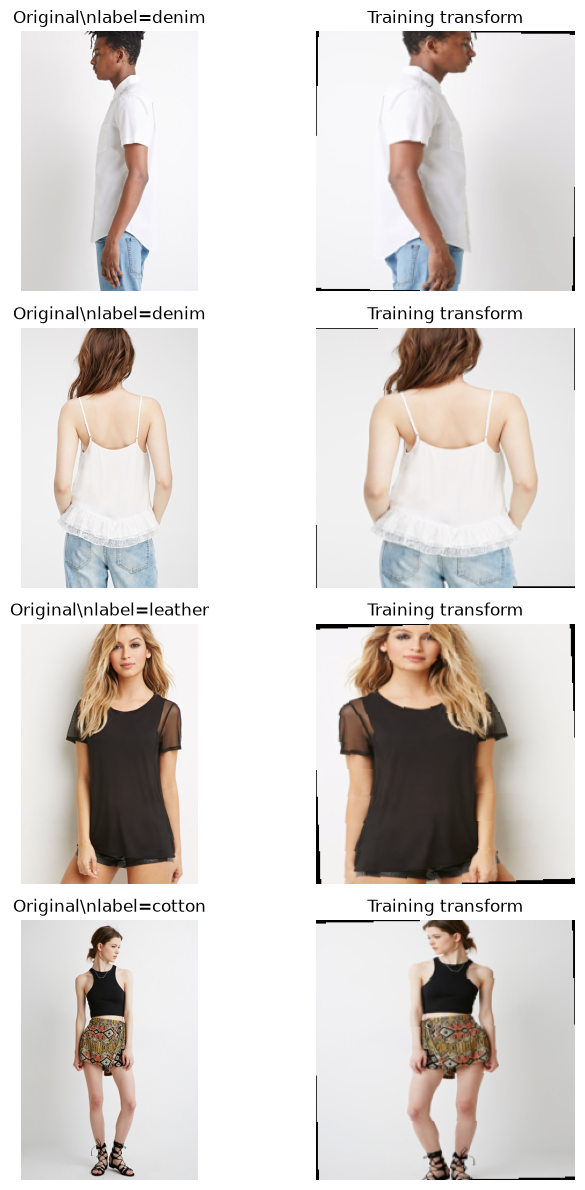

In [6]:
def tensor_to_display_image(tensor):
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.asarray(CLIP_STD) + np.asarray(CLIP_MEAN)
    return np.clip(image, 0, 1)

sample_rows = train_df.sample(min(4, len(train_df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(len(sample_rows), 2, figsize=(8, max(3, 3 * len(sample_rows))))
axes = np.atleast_2d(axes)
for row_index, (_, row) in enumerate(sample_rows.iterrows()):
    resolved_image_path = (PROJECT_ROOT / Path(row['image_path'])).resolve()
    if not resolved_image_path.is_file():
        raise FileNotFoundError(f'Referenced image is missing: {resolved_image_path}')
    with Image.open(resolved_image_path) as image:
        original = image.convert('RGB')
        transformed = train_transform(original)
    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title('Original\\nlabel={}'.format(row['target_label']))
    axes[row_index, 1].imshow(tensor_to_display_image(transformed))
    axes[row_index, 1].set_title('Training transform')
    axes[row_index, 0].axis('off')
    axes[row_index, 1].axis('off')
fig.tight_layout()
plt.show()
plt.close(fig)

## 7. Preprocessing summary and conclusion

The summary is generated from the actual run and records the selected target, exclusions, class distribution, split sizes, and output locations.

In [7]:
summary = {
    'random_state': RANDOM_STATE,
    'image_size': IMAGE_SIZE,
    'validation_ratio': VALIDATION_RATIO,
    'test_ratio': TEST_RATIO,
    'fast_dev_run': FAST_DEV_RUN,
    'selected_target': TARGET_COLUMN,
    'selected_target_semantic_name': TARGET_NAME,
    'original_records': original_records,
    'removed_na_samples': removed_na_samples,
    'exclude_na_target': EXCLUDE_NA_TARGET,
    'min_class_samples': MIN_CLASS_SAMPLES,
    'rare_classes_removed': rare_labels,
    'removed_rare_class_samples': removed_rare_class_samples,
    'invalid_paths_excluded': len(invalid_paths),
    'duplicate_image_names': len(duplicate_image_names),
    'duplicate_target_records': duplicate_target_records,
    'conflicting_images': conflicting_images,
    'final_clean_records': len(manifest),
    'number_of_classes': len(class_labels),
    'class_distribution': {str(k): int(v) for k, v in manifest['target_label'].value_counts().items()},
    'train_count': len(train_df),
    'validation_count': len(validation_df),
    'test_count': len(test_df),
    'train_class_distribution': {str(k): int(v) for k, v in train_class_counts.items()},
    'class_weights_used': CLASS_WEIGHTS_USED,
    'class_weights': {str(k): float(v) for k, v in class_weights.items()} if CLASS_WEIGHTS_USED else {},
    'class_weights_source': 'train split only',
    'target_selection_summary': fabric_selection_report.to_dict(orient='records'),
    'outputs': [
        str(INTERIM_ROOT / 'deepfashion_visual_manifest.csv'),
        str(INTERIM_ROOT / 'deepfashion_visual_train.csv'),
        str(INTERIM_ROOT / 'deepfashion_visual_validation.csv'),
        str(INTERIM_ROOT / 'deepfashion_visual_test.csv'),
        str(INTERIM_ROOT / 'deepfashion_visual_label_mapping.json'),
        str(INTERIM_ROOT / 'deepfashion_visual_preprocessing_summary.json'),
    ],
}
(INTERIM_ROOT / 'deepfashion_visual_preprocessing_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
display(Markdown(f'''### Preprocessing summary

- Selected semantic target: **{TARGET_NAME}** (`{TARGET_COLUMN}`), using human-readable fabric labels.
- Original records: **{original_records:,}**; removed explicit `NA` records: **{removed_na_samples:,}**; removed rare-class records: **{removed_rare_class_samples:,}**.
- Rare classes below **{MIN_CLASS_SAMPLES}** samples were reported and excluded from supervised modeling; they were not silently merged.
- Final clean records: **{len(manifest):,}** across **{len(class_labels)}** classes.
- Splits are reproducible, stratified, and disjoint. Class weights, when used, are calculated from the training split only.

### Conclusion

The artifacts are ready for downstream CLIP feature extraction and transfer learning using the explicit `lower_fabric` target. Label quality limitations remain: ID `7` is a real `NA` annotation and rare classes may be excluded under the configured policy. No model was trained and no raw DeepFashion file was modified.'''))

### Preprocessing summary

- Selected semantic target: **lower_fabric** (`texture/fabric_ann.txt__value_2`), using human-readable fabric labels.
- Original records: **44,096**; removed explicit `NA` records: **1,326**; removed rare-class records: **15**.
- Rare classes below **100** samples were reported and excluded from supervised modeling; they were not silently merged.
- Final clean records: **42,755** across **6** classes.
- Splits are reproducible, stratified, and disjoint. Class weights, when used, are calculated from the training split only.

### Conclusion

The artifacts are ready for downstream CLIP feature extraction and transfer learning using the explicit `lower_fabric` target. Label quality limitations remain: ID `7` is a real `NA` annotation and rare classes may be excluded under the configured policy. No model was trained and no raw DeepFashion file was modified.